# Machine_Learning

---

## Load Dataset

In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import platform

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
data = pd.read_csv("../../data/processed/integrated_data.csv")
data.head()

print(data.shape)

(100000, 22)


## Target

In [3]:
target = "is_churn"

print(data[target].value_counts())
print(data[target].value_counts(normalize=True))

is_churn
0    91049
1     8951
Name: count, dtype: int64
is_churn
0    0.91049
1    0.08951
Name: proportion, dtype: float64


In [4]:
data.isna().sum()

msno                          0
is_churn                      0
city                      11352
bd                        11352
gender                    60169
registered_via            11352
registration_init_time    11352
transaction_count             0
cancel_count                  0
total_payment                 0
last_auto_renew             138
last_is_cancel              138
last_plan_days              138
days_to_expire              138
cancel_on_last_date         138
activity_days                 0
total_secs                    0
total_num_100                 0
total_num_unq                 0
days_since_last_log       18281
has_transaction               0
has_log                       0
dtype: int64

## 평가 & 학습 데이터셋

In [5]:
# 8:2 분할
from sklearn.model_selection import train_test_split

train, valid = train_test_split(
    data,
    test_size=0.2,
    stratify=data[target],
    random_state=42
)

train = train.copy()
valid = valid.copy()

train.shape, valid.shape

((80000, 22), (20000, 22))

# EDA

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   msno                    100000 non-null  object 
 1   is_churn                100000 non-null  int64  
 2   city                    88648 non-null   float64
 3   bd                      88648 non-null   float64
 4   gender                  39831 non-null   object 
 5   registered_via          88648 non-null   float64
 6   registration_init_time  88648 non-null   float64
 7   transaction_count       100000 non-null  float64
 8   cancel_count            100000 non-null  float64
 9   total_payment           100000 non-null  float64
 10  last_auto_renew         99862 non-null   float64
 11  last_is_cancel          99862 non-null   float64
 12  last_plan_days          99862 non-null   float64
 13  days_to_expire          99862 non-null   float64
 14  cancel_on_last_date  

In [8]:
# 컬럼별 결측치 개수와 비율 확인
null_ratio = train.isnull().mean()

pd.DataFrame({"결측치 비율": null_ratio}).sort_values("결측치 비율", ascending=False)

,결측치 비율
gender,0.602125
days_since_last_log,0.183138
bd,0.113113
registered_via,0.113113
registration_init_time,0.113113
city,0.113113
days_to_expire,0.001350
last_auto_renew,0.001350
last_is_cancel,0.001350
last_plan_days,0.001350


In [9]:
train.describe()

,is_churn,city,bd,registered_via,registration_init_time,transaction_count,cancel_count,total_payment,last_auto_renew,last_is_cancel,last_plan_days,days_to_expire,cancel_on_last_date,activity_days,total_secs,total_num_100,total_num_unq,days_since_last_log,has_transaction,has_log
count,80000.000000,70951.000000,70951.000000,70951.000000,7.095100e+04,80000.000000,80000.000000,80000.000000,79892.000000,79892.000000,79892.000000,79892.000000,79892.000000,80000.000000,8.000000e+04,80000.000000,80000.000000,65349.000000,80000.000000,80000.000000
mean,0.089512,5.909008,13.503249,6.897140,2.013251e+07,15.773450,0.258663,2126.222500,0.881578,0.009701,35.181457,19.078631,0.017611,38.901863,3.077090e+05,1176.734175,1136.247537,4.373609,0.998650,0.816863
std,0.285484,6.428790,20.456424,1.934361,3.019727e+04,8.683796,0.564522,1258.497806,0.323110,0.098013,38.810508,26.764915,0.131535,31.051256,4.602965e+05,1888.534219,1519.355226,11.719927,0.036718,0.386782
min,0.000000,1.000000,-51.000000,3.000000,2.004033e+07,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-1156.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,7.000000,2.012021e+07,8.000000,0.000000,1043.000000,1.000000,0.000000,30.000000,9.000000,0.000000,6.000000,1.559313e+04,51.000000,70.000000,0.000000,1.000000,1.000000
50%,0.000000,1.000000,0.000000,7.000000,2.014052e+07,16.000000,0.000000,1881.000000,1.000000,0.000000,30.000000,18.000000,0.000000,38.000000,1.576764e+05,574.000000,635.000000,0.000000,1.000000,1.000000
75%,0.000000,13.000000,27.000000,9.000000,2.016012e+07,23.000000,0.000000,3278.000000,1.000000,0.000000,30.000000,26.000000,0.000000,68.000000,4.059961e+05,1515.000000,1592.000000,3.000000,1.000000,1.000000
max,1.000000,22.000000,1820.000000,13.000000,2.017023e+07,59.000000,11.000000,7450.000000,1.000000,1.000000,450.000000,892.000000,1.000000,90.000000,7.622046e+06,85874.000000,27088.000000,89.000000,1.000000,1.000000


In [11]:
# 두 집단의 최근 이용 활동 중앙값 비교
log_cols = ["activity_days", "total_secs", "total_num_100", "total_num_unq"]
display(train.groupby(target)[log_cols].median().T)


is_churn,0,1
activity_days,37.000,39.000
total_secs,155543.692,179283.702
total_num_100,566.000,661.000
total_num_unq,626.000,738.000


In [12]:
# 자동 갱신 여부별 고객 수와 이탈률 비교
summary = train.groupby("last_auto_renew", dropna=False)[target].agg(
    customers="size", churn_rate="mean"
)
display(summary)


,customers,churn_rate
last_auto_renew,,
0.0,9461,0.412113
1.0,70431,0.045307
NaN,108,0.657407


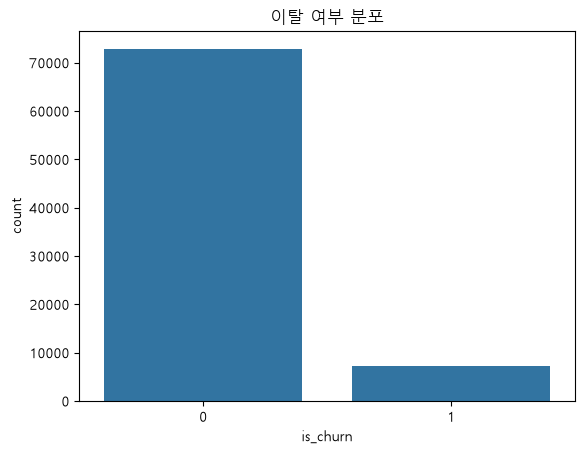

In [53]:
# 타깃 분포
sns.countplot(data=train, x="is_churn")
plt.title("이탈 여부 분포")
plt.show()

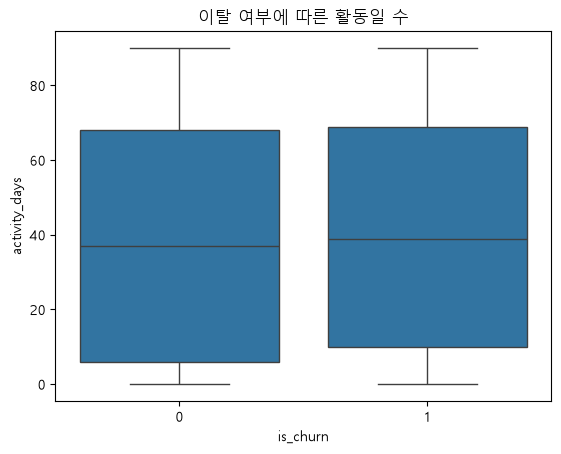

In [54]:
# 활동일 수 비교
sns.boxplot(data=train, x="is_churn", y="activity_days")
plt.title("이탈 여부에 따른 활동일 수")
plt.show()

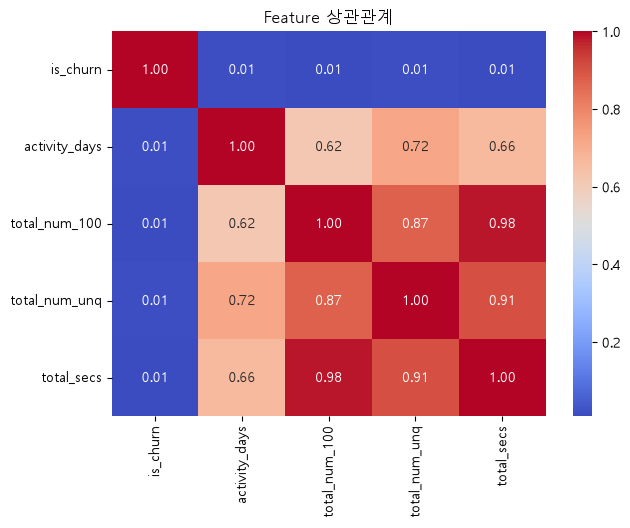

In [55]:
# 피처 상관관계
corr_cols = [
    "is_churn",
    "activity_days",
    "total_num_100",
    "total_num_unq",
    "total_secs"
]

plt.figure(figsize=(7, 5))

sns.heatmap(
    train[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature 상관관계")
plt.show()

# Feature Engineering

## user_logs Features

In [59]:
OBS_DAYS = 90

for frame in (train, valid):

    days = pd.to_numeric(
        frame["activity_days"], errors="coerce"
    )

    active_days = days.replace(0, np.nan)

    # H1. Activity Rate
    frame["activity_rate"] = days / OBS_DAYS

    # H2. Listening Time per Active Day
    frame["secs_per_active_day"] = (
        frame["total_secs"] / active_days
    )

    # H3. Completed Songs per Active Day
    frame["completed_per_active_day"] = (
        frame["total_num_100"] / active_days
    )

    # H4. Unique Songs per Active Day
    frame["unq_per_active_day"] = (
        frame["total_num_unq"] / active_days
    )

In [60]:
# Feature Comparison by Churn

feature_cols = [
    "activity_rate",
    "secs_per_active_day",
    "completed_per_active_day",
    "unq_per_active_day"
]

display(
    train.groupby(target)[feature_cols]
    .median()
    .T
)

is_churn,0,1
activity_rate,0.411111,0.433333
secs_per_active_day,4964.654232,5347.609040
completed_per_active_day,18.321634,19.641975
unq_per_active_day,20.333333,21.947368


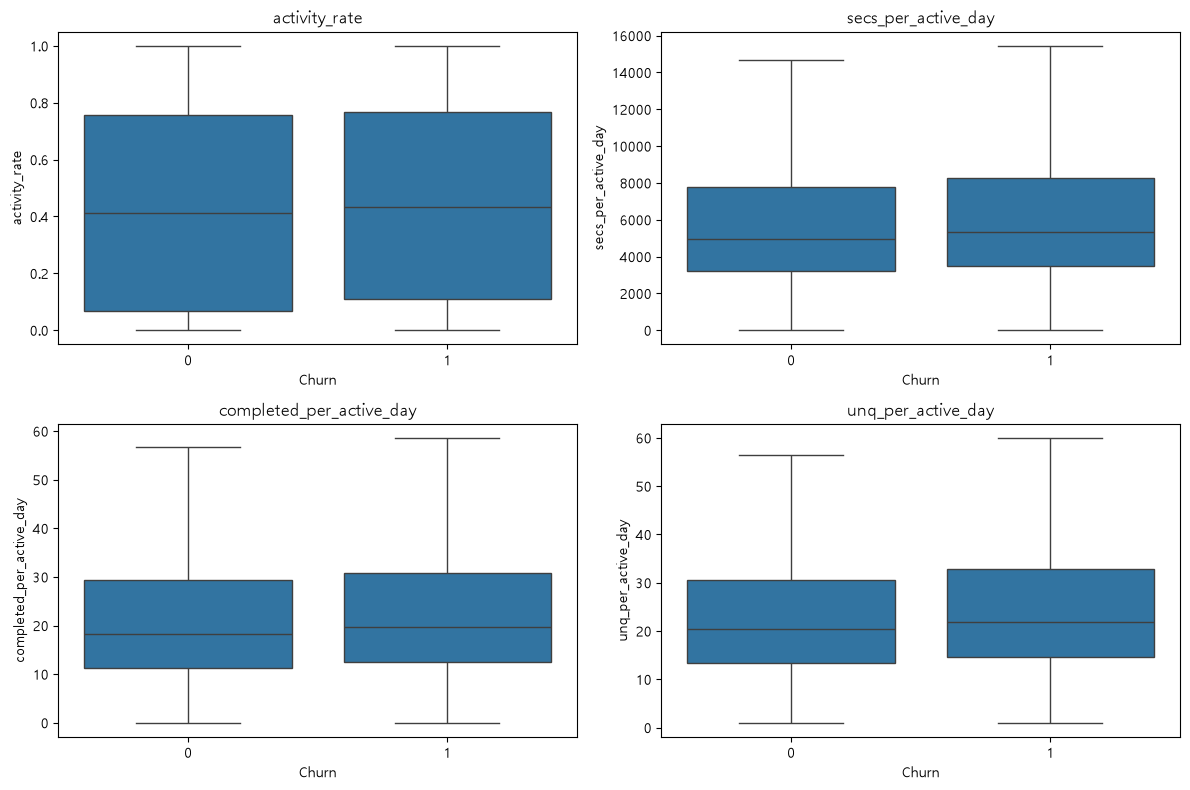

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flat, feature_cols):

    sns.boxplot(
        data=train,
        x=target,
        y=col,
        ax=ax,
        showfliers=False
    )

    ax.set_title(col)
    ax.set_xlabel("Churn")

plt.tight_layout()
plt.show()

In [63]:
display(
    train.groupby(target)["days_since_last_log"]
    .agg(["mean", "median", "max"])
)

,mean,median,max
is_churn,,,
0,4.408167,0.0,89.0
1,4.039948,0.0,89.0


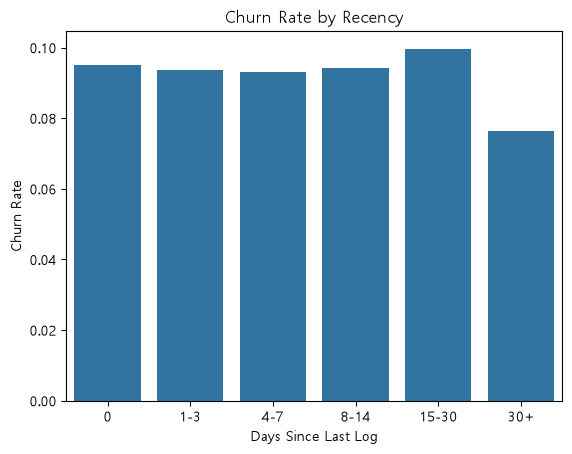

In [64]:
# Recency Groups
train["recency_group"] = pd.cut(
    train["days_since_last_log"],
    bins=[-1, 0, 3, 7, 14, 30, np.inf],
    labels=["0", "1-3", "4-7", "8-14", "15-30", "30+"]
)

recency_churn = (
    train.groupby("recency_group", observed=True)[target]
    .mean()
    .reset_index()
)

sns.barplot(data=recency_churn, x="recency_group", y=target)

plt.title("Churn Rate by Recency")
plt.xlabel("Days Since Last Log")
plt.ylabel("Churn Rate")
plt.show()

In [65]:
display(
    train.groupby("recency_group", observed=True)[target]
    .agg(
        customers="count",
        churn_rate="mean"
    )
)

,customers,churn_rate
recency_group,,
0,36141,0.094989
1-3,15297,0.093548
4-7,5463,0.092989
8-14,3109,0.094243
15-30,2578,0.099690
30+,2761,0.076422


## Additional Features

In [66]:
for frame in (train, valid):

    # H1. 최근 7일간 미이용 고객
    frame["inactive_7days"] = (
        frame["days_since_last_log"].gt(7) |
        frame["has_log"].eq(0)
    ).astype(int)

    # H2. 청취시간 1시간당 완청 곡 수
    listening_hours = frame["total_secs"].replace(0, np.nan) / 3600

    frame["completed_per_hour"] = (
        frame["total_num_100"] / listening_hours
    )

    # H3. 과거 거래 취소 비율
    tx_count = frame["transaction_count"].replace(0, np.nan)

    frame["cancel_rate"] = (
        frame["cancel_count"] / tx_count
    )

    # H4. 자동 갱신 미사용 + 낮은 활동량
    frame["no_auto_renew_low_activity"] = (
        frame["last_auto_renew"].eq(0) &
        frame["activity_days"].le(5)
    ).astype(int)

    # H5. 장기 가입 + 낮은 활동량
    frame["long_tenure_low_activity"] = (
        frame["tenure_days"].ge(365) &
        frame["activity_days"].le(5)
    ).astype(int)

In [68]:
feature_cols = [
    "inactive_7days",
    "completed_per_hour",
    "cancel_rate",
    "no_auto_renew_low_activity",
    "long_tenure_low_activity"
]

display(
    train.groupby(target)[feature_cols]
    .mean()
    .T
    .round(4)
)

is_churn,0,1
inactive_7days,0.2926,0.2498
completed_per_hour,13.0219,13.0727
cancel_rate,0.0131,0.0228
no_auto_renew_low_activity,0.0021,0.0528
long_tenure_low_activity,0.0942,0.1128


In [70]:
binary_features = [
    "inactive_7days",
    "no_auto_renew_low_activity",
    "long_tenure_low_activity"
]

for col in binary_features:
    print(f"\n[{col}]")

    display(
        train.groupby(col)[target]
        .agg(
            customers="count",
            churn_rate="mean"
        )
        .round(4)
    )


[inactive_7days]


,customers,churn_rate
inactive_7days,,
0,56901,0.0944
1,23099,0.0774



[no_auto_renew_low_activity]


,customers,churn_rate
no_auto_renew_low_activity,,
0,79467,0.0854
1,533,0.7092



[long_tenure_low_activity]


,customers,churn_rate
long_tenure_low_activity,,
0,72333,0.0878
1,7667,0.1054


# Data Preprocessing

In [71]:
# 1. 로그 결측치 처리

for frame in (train, valid):

    frame["days_since_last_log"] = (
        frame["days_since_last_log"].fillna(90)
    )

    # 무한대 처리
    frame.replace([np.inf, -np.inf], np.nan, inplace=True)

In [76]:
# 2. Features / Target Split

excluded = [
    "msno",
    "registration_init_time",
    "bd",
    "recency_group"  # EDA용 컬럼 제외
]

x_train = train.drop(
    columns=[target] + excluded,
    errors="ignore"
).copy()

x_valid = valid.drop(
    columns=[target] + excluded,
    errors="ignore"
).copy()

y_train = train[target].astype(int)
y_valid = valid[target].astype(int)

In [77]:
# 3. Feature Types

cat_cols = [
    "city",
    "gender",
    "registered_via"
]

cat_cols = [
    col for col in cat_cols
    if col in x_train.columns
]

num_cols = [
    col for col in x_train.columns
    if col not in cat_cols
]

print("Categorical:", cat_cols)
print("Numerical:", num_cols)

Categorical: ['city', 'gender', 'registered_via']
Numerical: ['transaction_count', 'cancel_count', 'total_payment', 'last_auto_renew', 'last_is_cancel', 'last_plan_days', 'days_to_expire', 'cancel_on_last_date', 'activity_days', 'total_secs', 'total_num_100', 'total_num_unq', 'days_since_last_log', 'has_transaction', 'has_log', 'activity_rate', 'secs_per_active_day', 'completed_per_active_day', 'unq_per_active_day', 'tenure_days', 'new_user_low_activity', 'auto_renew_low_activity', 'inactive_7days', 'completed_per_hour', 'cancel_rate', 'no_auto_renew_low_activity', 'long_tenure_low_activity']


In [78]:
# 4. Preprocessing

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# 수치형
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="median",
        keep_empty_features=True
    ))
])

# 범주형
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="unknown"
    )),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# 데이터 타입 정리
for frame in (x_train, x_valid):

    for col in num_cols:
        frame[col] = pd.to_numeric(
            frame[col], errors="coerce"
        )

    for col in cat_cols:
        frame[col] = (
            frame[col]
            .astype("string")
            .fillna("unknown")
            .astype(str)
        )

# 통합 전처리
preprocess = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# 학습 데이터 기준
x_train_ready = preprocess.fit_transform(x_train)

# 검증 데이터에는 transform만 적용
x_valid_ready = preprocess.transform(x_valid)

print("Train:", x_train_ready.shape)
print("Valid:", x_valid_ready.shape)

Train: (80000, 58)
Valid: (20000, 58)


In [79]:
# 5. Validation

print("Train NaN:", np.isnan(x_train_ready).sum())
print("Valid NaN:", np.isnan(x_valid_ready).sum())

print("Train Inf:", np.isinf(x_train_ready).sum())
print("Valid Inf:", np.isinf(x_valid_ready).sum())

print("Feature Count:", x_train_ready.shape[1])

Train NaN: 0
Valid NaN: 0
Train Inf: 0
Valid Inf: 0
Feature Count: 58


# Modeling

In [80]:
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    roc_curve
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 클래스 불균형 가중치
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# 모델 설정
models = {
    "CatBoost": CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        random_seed=42,
        verbose=False,
        thread_count=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        class_weight="balanced",
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        eval_metric="logloss",
        scale_pos_weight=pos_weight,
        random_state=42,
        n_jobs=-1
    )
}

# 학습 및 평가
results = []
predictions = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(x_train_ready, y_train)

    proba = model.predict_proba(x_valid_ready)[:, 1]
    pred = (proba >= 0.5).astype(int)

    predictions[name] = proba

    results.append({
        "model": name,
        "ROC-AUC": roc_auc_score(y_valid, proba),
        "PR-AUC": average_precision_score(y_valid, proba),
        "F1@0.5": f1_score(y_valid, pred)
    })

# 성능 비교
result_df = (
    pd.DataFrame(results)
    .sort_values("ROC-AUC", ascending=False)
    .reset_index(drop=True)
)

display(result_df.round(4))

Training CatBoost...
Training LightGBM...
Training XGBoost...


,model,ROC-AUC,PR-AUC,F1@0.5
0,CatBoost,0.8977,0.6870,0.6029
1,LightGBM,0.8944,0.6801,0.5598
2,XGBoost,0.8886,0.6746,0.5666


## ROC Curve

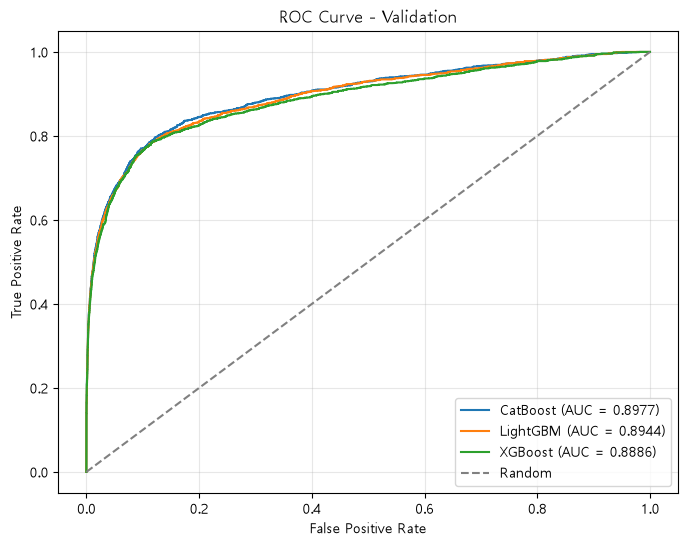

In [84]:
plt.figure(figsize=(8, 6))

for name, proba in predictions.items():

    fpr, tpr, _ = roc_curve(y_valid, proba)
    auc = roc_auc_score(y_valid, proba)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.4f})"
    )

plt.plot(
    [0, 1], [0, 1],
    "--", color="gray",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Validation")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

## Best Model

In [85]:
best_name = result_df.iloc[0]["model"]
best_model = models[best_name]

print("Best Model:", best_name)
print("ROC-AUC:", result_df.iloc[0]["ROC-AUC"])

Best Model: CatBoost
ROC-AUC: 0.8977228884614322


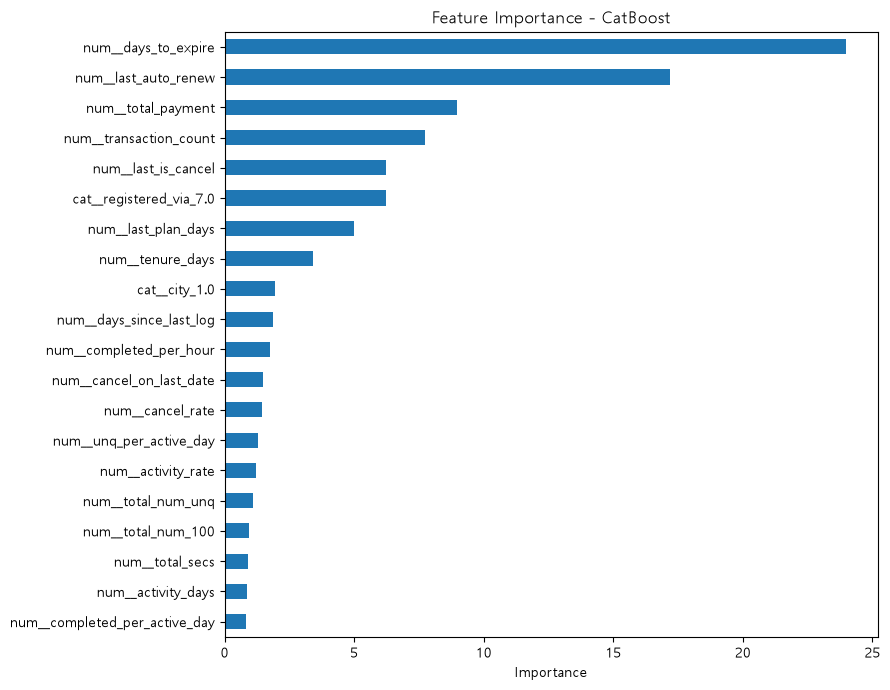

In [89]:
# Feature Importance TOP 20
best_name = result_df.iloc[0]["model"]
best_model = models[best_name]

pd.Series(
    best_model.feature_importances_,
    index=preprocess.get_feature_names_out()
).nlargest(20).sort_values().plot.barh(figsize=(9, 7))

plt.title(f"Feature Importance - {best_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Result

### 1. 개요
* KKBOX 고객 100,000명의 통합 데이터를 활용하여 고객 이탈 예측 모델 학습
* 이용 행동 및 결제 정보를 기반으로 피처 엔지니어링을 진행
* CatBoost, LightGBM, XGBoost의 성능을 비교
* ROC-AUC를 주요 평가지표로 사용

### 2. 결과
* 부스팅 모델에서 ROC-AUC 약 0.89점 확인
* 추가 피처 엔지니어링을 통해 활동 빈도, 청취 패턴, 결제 행동을 반영
* Feature Importance를 통해 이탈 예측에 활용되는 주요 피처를 확인
* PR-AUC와 F1-score를 함께 확인하여 불균형 데이터에서의 분류 성능을 평가

### 3. 결론
부스팅 모델들이 유사한 ROC-AUC 성능을 보였으며, 고객의 이용 행동 및 결제 정보가 이탈 예측에 활용될 수 있음을 확인함